# Detección de uso de mascarillas con una CNN y OpenCV

**Maestría en Analítica de Datos - Visión por Computador — Ferney Araujo**

Pasos dentro del cuadernillo:

1. Se carga y preprocesa el dataset *Face Mask Detection*.
2. Se construye una red neuronal convolucional (CNN) con TensorFlow / Keras.
3. Se entrenamos el modelo.
4. Con OpenCV, se le pasan fotos y se detecta y clasifican los rostros.

El dataset tiene 853 fotos con anotaciones (una caja y una etiqueta por rostro) en
3 clases: `with_mask`, `without_mask` y `mask_weared_incorrect`.

**Idea:** recortamos cada rostro anotado y entrenamos un clasificador de 3 clases.
Después, dada una imagen nueva, OpenCV localiza los rostros y la CNN decide la clase.

## 1. Preparación

In [142]:
# Si hace falta instalar algo, quita el comentario:
# !pip install kagglehub tensorflow "opencv-python<5" scikit-learn matplotlib

In [143]:
import os
import glob
import xml.etree.ElementTree as ET

import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = 100                       # tamaño al que redimensionamos cada rostro
CLASSES = ["with_mask", "without_mask", "mask_weared_incorrect"]
NOMBRES = ["Con mascarilla", "Sin mascarilla", "Mal puesta"]
print("TensorFlow", tf.__version__, "| OpenCV", cv2.__version__)

TensorFlow 2.21.0 | OpenCV 4.10.0


## 2. Descargar y cargar el dataset

In [144]:
import kagglehub

ruta = kagglehub.dataset_download("andrewmvd/face-mask-detection")
print("Dataset en:", ruta)

CARPETA_IMAGENES = os.path.join(ruta, "images")
CARPETA_XML = os.path.join(ruta, "annotations")

Dataset en: /Users/ferney/.cache/kagglehub/datasets/andrewmvd/face-mask-detection/versions/1


Cada anotación es un XML con una etiqueta y una caja (`xmin, ymin, xmax, ymax`)
por rostro. Recorremos todos los XML, recortamos los rostros y guardamos cada
recorte con su etiqueta.

In [145]:
rostros = []
etiquetas = []

for archivo_xml in glob.glob(os.path.join(CARPETA_XML, "*.xml")):
    raiz = ET.parse(archivo_xml).getroot()
    nombre_imagen = raiz.find("filename").text
    imagen = cv2.imread(os.path.join(CARPETA_IMAGENES, nombre_imagen))

    for objeto in raiz.findall("object"):
        etiqueta = objeto.find("name").text
        caja = objeto.find("bndbox")
        x1 = int(caja.find("xmin").text)
        y1 = int(caja.find("ymin").text)
        x2 = int(caja.find("xmax").text)
        y2 = int(caja.find("ymax").text)

        recorte = imagen[y1:y2, x1:x2]
        # recorte = imagen
        if recorte.size == 0:
            continue

        recorte = cv2.resize(recorte, (IMG_SIZE, IMG_SIZE))
        recorte = cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB)  # OpenCV usa BGR

        rostros.append(recorte)
        etiquetas.append(CLASSES.index(etiqueta))

X = np.array(rostros)
y = np.array(etiquetas)

print("Rostros recortados:", X.shape)
for i, nombre in enumerate(CLASSES):
    print(f"  {nombre}: {(y == i).sum()}")

libpng warning: iCCP: Not recognizing known sRGB profile that has been edited


Rostros recortados: (4072, 100, 100, 3)
  with_mask: 3232
  without_mask: 717
  mask_weared_incorrect: 123


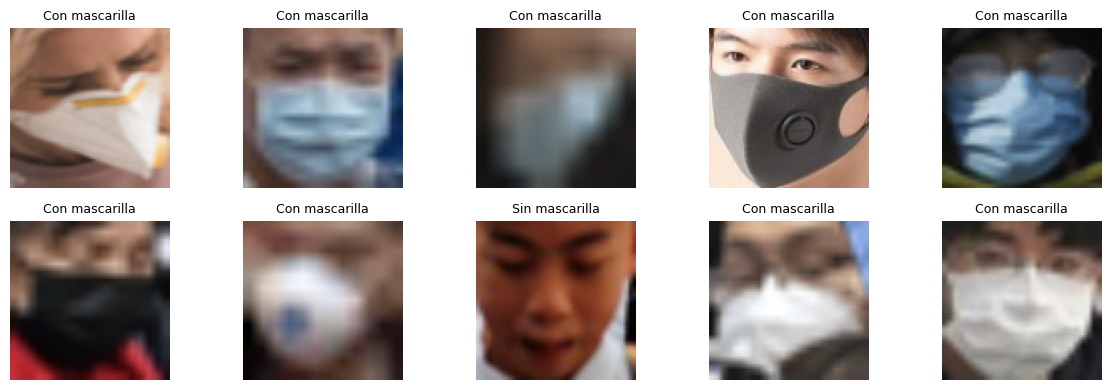

In [146]:
# Ver algunos rostros recortados
plt.figure(figsize=(12, 4))
for k in range(10):
    plt.subplot(2, 5, k + 1)
    i = np.random.randint(len(X))
    plt.imshow(X[i])
    plt.title(NOMBRES[y[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

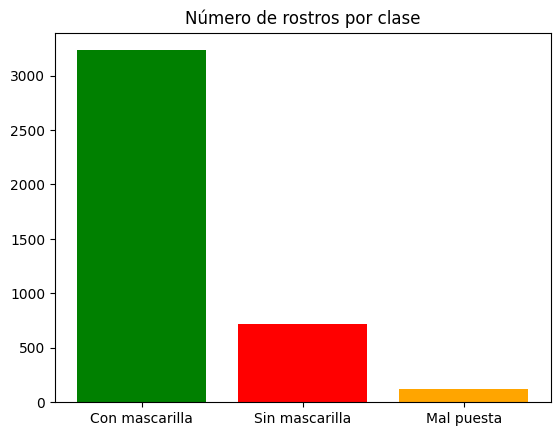

In [147]:
# El dataset está desbalanceado
conteo = [ (y == i).sum() for i in range(3) ]
plt.bar(NOMBRES, conteo, color=["green", "red", "orange"])
plt.title("Número de rostros por clase")
plt.show()

## 3. Preparar los datos para el modelo

Normalizamos los píxeles a `[0, 1]` y separamos en entrenamiento y prueba.
Como hay muchas más imágenes de una clase que de otra, calculamos un *peso por clase*
para que el modelo no ignore a las minoritarias.

In [148]:
X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Entrenamiento:", X_train.shape, " | Prueba:", X_test.shape)

pesos = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=y_train)
pesos = np.minimum(pesos, 3.0)   # limitamos el peso para no exagerar con la clase rara
peso_por_clase = dict(enumerate(pesos))
print("Peso por clase:", {i: round(w, 2) for i, w in peso_por_clase.items()})

Entrenamiento: (3257, 100, 100, 3)  | Prueba: (815, 100, 100, 3)
Peso por clase: {0: np.float64(0.42), 1: np.float64(1.89), 2: np.float64(3.0)}


## 4. Construir la CNN

Una CNN sencilla: tres bloques de convolución + *pooling*, y al final capas densas
para clasificar en 3 clases. Las dos primeras capas hacen *data augmentation*
(giros y rotaciones aleatorias) solo durante el entrenamiento.

In [149]:
modelo = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),
    
    # Agrego una capa adicional pa ver si mejora o no
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    
    layers.Dropout(0.5),
    layers.Dense(3, activation="softmax"),
])

modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
modelo.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_6 (RandomFlip)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_6               │ (None, 100, 100, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,438,019 (5.49 MB)

 Trainable params: 1,438,019 (5.49 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenar el modelo

`EarlyStopping` detiene el entrenamiento si el modelo deja de mejorar y se queda
con los mejores pesos.

In [150]:
parada = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=5, restore_best_weights=True
)

historia = modelo.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=peso_por_clase,
    callbacks=[parada],
)

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.8088 - loss: 0.5658 - val_accuracy: 0.9356 - val_loss: 0.3064
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.8964 - loss: 0.3522 - val_accuracy: 0.9110 - val_loss: 0.2794
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.9109 - loss: 0.3201 - val_accuracy: 0.9126 - val_loss: 0.2538
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.9002 - loss: 0.3115 - val_accuracy: 0.9172 - val_loss: 0.2671
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.9056 - loss: 0.2867 - val_accuracy: 0.9172 - val_loss: 0.2371
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.8990 - loss: 0.2813 - val_accuracy: 0.9294 - val_loss: 0.2370


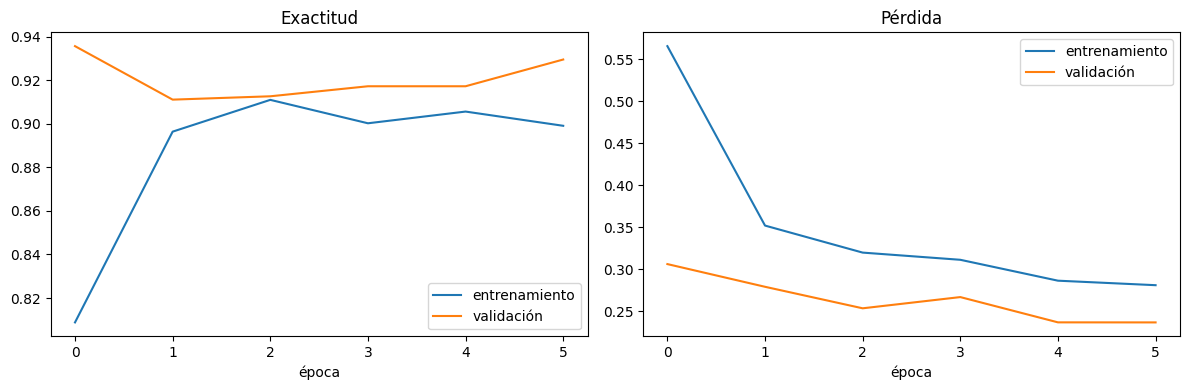

In [151]:
# Curvas de entrenamiento
h = historia.history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(h["accuracy"], label="entrenamiento")
plt.plot(h["val_accuracy"], label="validación")
plt.title("Exactitud"); plt.xlabel("época"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h["loss"], label="entrenamiento")
plt.plot(h["val_loss"], label="validación")
plt.title("Pérdida"); plt.xlabel("época"); plt.legend()

plt.tight_layout()
plt.show()

## 6. Evaluar el modelo

In [152]:
loss, acc = modelo.evaluate(X_test, y_test, verbose=0)
print(f"Exactitud en prueba: {acc:.3f}")

y_pred = modelo.predict(X_test, verbose=0).argmax(axis=1)
print()
print(classification_report(y_test, y_pred, target_names=CLASSES, zero_division=0))

Exactitud en prueba: 0.897

                       precision    recall  f1-score   support

            with_mask       0.95      0.93      0.94       647
         without_mask       0.81      0.85      0.83       143
mask_weared_incorrect       0.28      0.36      0.32        25

             accuracy                           0.90       815
            macro avg       0.68      0.71      0.70       815
         weighted avg       0.90      0.90      0.90       815



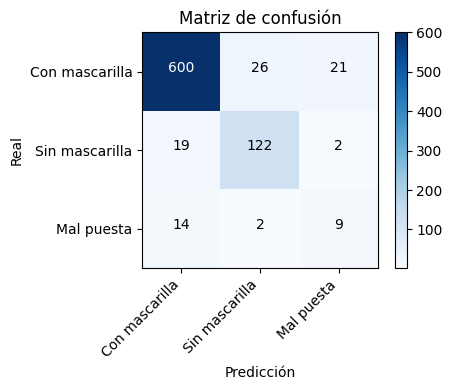

In [153]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1, 2], NOMBRES, rotation=45, ha="right")
plt.yticks([0, 1, 2], NOMBRES)
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.title("Matriz de confusión"); plt.colorbar()
plt.tight_layout()
plt.show()

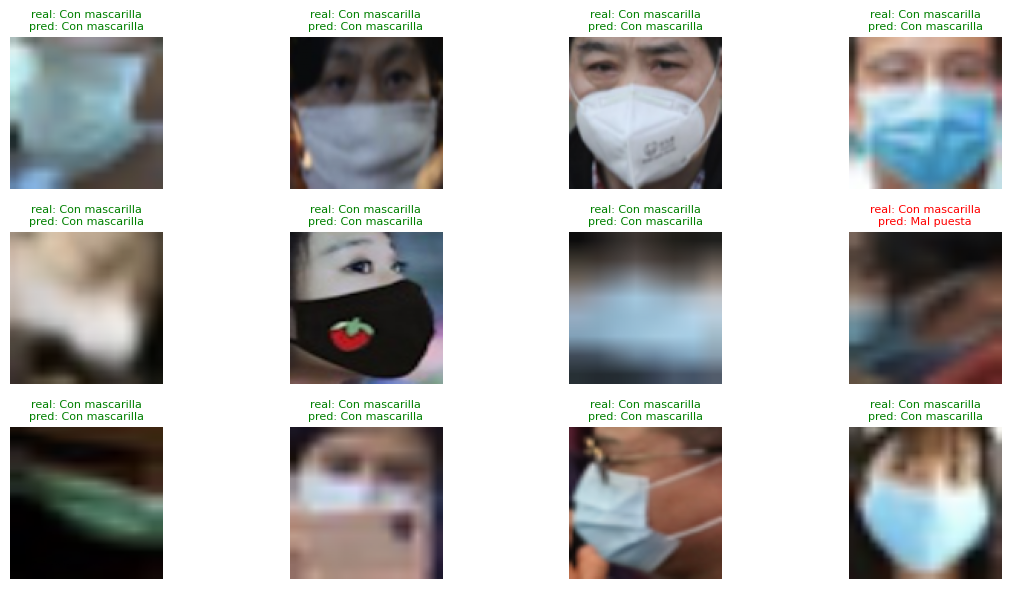

In [154]:
# Algunas predicciones
plt.figure(figsize=(12, 6))
for k in range(12):
    i = np.random.randint(len(X_test))
    plt.subplot(3, 4, k + 1)
    plt.imshow(X_test[i])
    color = "green" if y_pred[i] == y_test[i] else "red"
    plt.title(f"real: {NOMBRES[y_test[i]]}\npred: {NOMBRES[y_pred[i]]}",
              color=color, fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [155]:
modelo.save("modelo_mascarillas.keras")
print("Modelo guardado en modelo_mascarillas.keras")

Modelo guardado en modelo_mascarillas.keras


## 7. Detección sobre una imagen con OpenCV

Le pasamos una foto ya tomada (un archivo de imagen) y el programa:

1. Encuentra los rostros con un *clasificador Haar cascade* de OpenCV
   (`cv2.CascadeClassifier`, ya incluido en OpenCV).
2. Recorta cada rostro y la CNN predice si lleva mascarilla.
3. Dibuja el recuadro y la etiqueta sobre la imagen.

In [156]:
ruta_haar = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
detector_rostros = cv2.CascadeClassifier(ruta_haar)
print("Detector de rostros cargado:", not detector_rostros.empty())

Detector de rostros cargado: True


In [157]:
COLORES = [(0, 200, 0), (0, 0, 255), (0, 165, 255)]  # BGR: verde, rojo, naranja

def detectar_y_clasificar(imagen_bgr):
    gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
    rostros = detector_rostros.detectMultiScale(gris, scaleFactor=1.1,
                                                minNeighbors=5, minSize=(40, 40))
    resultado = imagen_bgr.copy()
    for (x, y, w, h) in rostros:
        recorte = imagen_bgr[y:y + h, x:x + w]
        recorte = cv2.resize(recorte, (IMG_SIZE, IMG_SIZE))
        recorte = cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB) / 255.0

        pred = modelo.predict(recorte[np.newaxis, ...], verbose=0)[0]
        clase = pred.argmax()
        texto = f"{NOMBRES[clase]} {pred[clase] * 100:.0f}%"

        cv2.rectangle(resultado, (x, y), (x + w, y + h), COLORES[clase], 2)
        cv2.putText(resultado, texto, (x, y - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, COLORES[clase], 2)
    return resultado

In [158]:
def clasificar_imagen(ruta_imagen):
    imagen = cv2.imread(ruta_imagen)
    if imagen is None:
        print("No se pudo abrir:", ruta_imagen)
        return
    salida = detectar_y_clasificar(imagen)

    cv2.imwrite("resultado.jpg", salida)   # guarda la imagen anotada
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(salida, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(os.path.basename(ruta_imagen))
    plt.show()

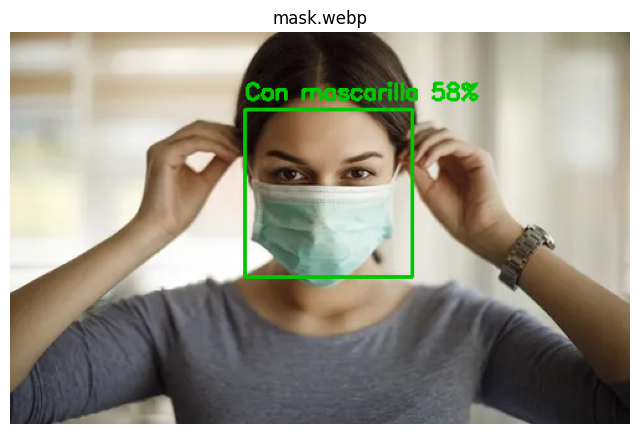

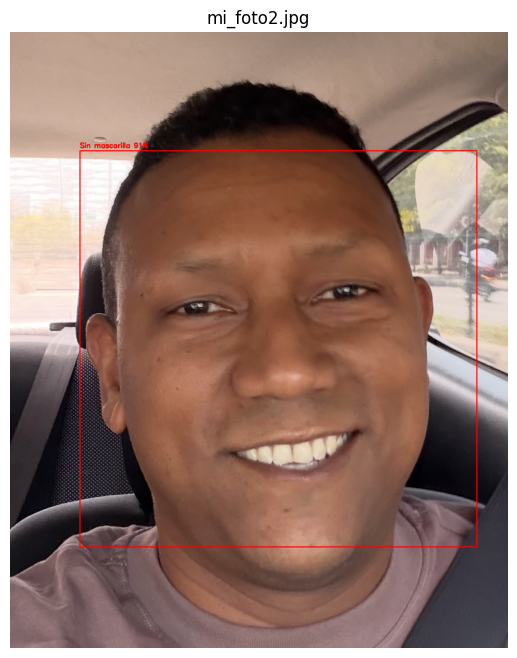

In [159]:
# Ejemplo de clasificación de imágenes locales
clasificar_imagen("images/mask.webp")
clasificar_imagen("images/mi_foto2.jpg")